<a href="https://colab.research.google.com/github/Iffraah96/Sales-Analysis-Project/blob/main/notebooks/sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Analysis Project

**Sales Analysis Project**

This project analyzes retail sales data from a Superstore dataset to uncover business insights related to sales performance, profitability, customer segments, product categories, and regional trends. The goal is to use data analytics techniques to identify key drivers of revenue and profit and provide recommendations that can support business decision-making.

**- Dataset Introduction:**
The dataset has been taken from kaggle. It consist of 9,994 retail transactions and includes information on:

1. Customer segments
2. Product categories and sub-categories
3. Sales and profit
4. Discounts and quantities
5. Geographic regions and states
6. Shipping modes

**- Variable Description:**

1. Ship Mode (Standard Class, Second Class, First Class, Same Day)
2. Segment (Consumer, Corporate, Home Office)
4. Country
5. City
6. State
7. Postal
8. Code
9. Region (West, East, Central, South)
10. Category (Office Supplies, Furniture, Technology)
11. Sub-Category
12. Sales
13. Quantity
14. Discount
15. Profit
3.


# Importing Libraries

In [4]:
# General Libraries
import numpy as np
import pandas as pd
import os
import math

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Supperissing warnings
import warnings
warnings.filterwarnings('ignore')

# Loading (Reading) the Dataset

In [5]:
df = pd.read_csv('SampleSuperstore.csv')

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [6]:
# Creating a copy of the dataset
SampleSuperstore = df.copy()

In [7]:
SampleSuperstore.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [8]:
SampleSuperstore.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


# EDA - Exploratory Data Analysis

In [9]:
df.size

129922

In [10]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [11]:
df.ndim

2

In [12]:
df.shape

(9994, 13)

In [13]:
df.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,int64
Region,object
Category,object
Sub-Category,object
Sales,float64


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [15]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [16]:
df.describe(include=object)

,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category
count,9994,9994,9994,9994,9994,9994,9994,9994
unique,4,3,1,531,49,4,3,17
top,Standard Class,Consumer,United States,New York City,California,West,Office Supplies,Binders
freq,5968,5191,9994,915,2001,3203,6026,1523


In [17]:
df['Ship Mode'].value_counts()

,count
Ship Mode,
Standard Class,5968
Second Class,1945
First Class,1538
Same Day,543


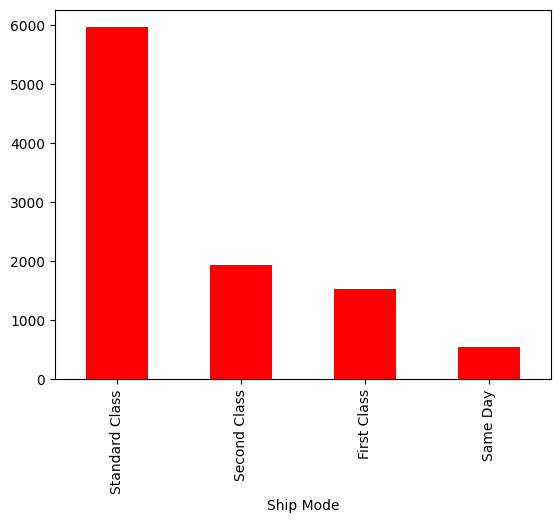

In [18]:
# Plotting the categorical values of column Ship Mode
df['Ship Mode'].value_counts().plot(kind='bar', color='red');

In [19]:
df['Segment'].value_counts()

,count
Segment,
Consumer,5191
Corporate,3020
Home Office,1783


In [20]:
df['Region'].value_counts()

,count
Region,
West,3203
East,2848
Central,2323
South,1620


In [21]:
df['Category'].value_counts()

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847


**Checking Missing Values**

In [22]:
# Let's check if there are any missing vales
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


# Business Overview

In [23]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = len(df)

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 9994


**Regional Sales**

In [24]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales

,Sales
Region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


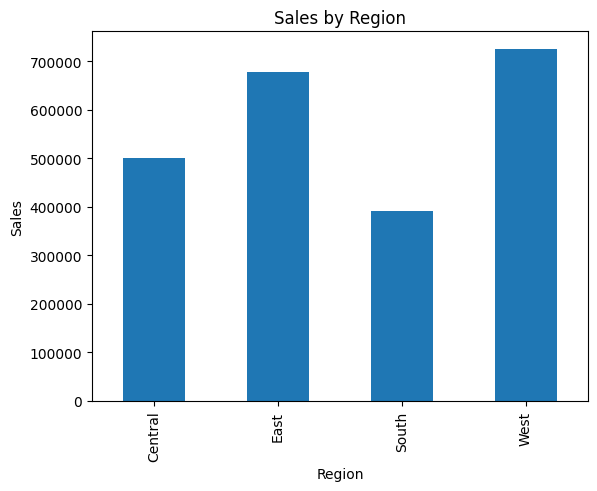

In [38]:
region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.ylabel('Sales')

plt.savefig(
    'visuals/sales_by_region.png',
    bbox_inches='tight'
)

plt.show()

The West region generated the highest revenue and should be prioritized for growth initiatives.

**Category Analysis**

In [26]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


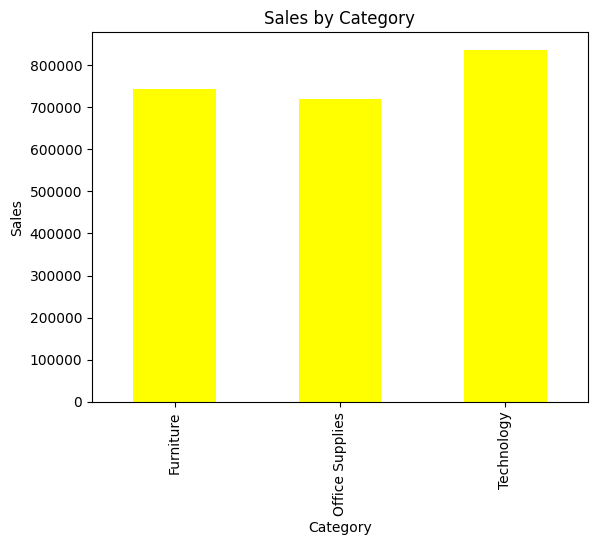

In [39]:
category_sales.plot(kind='bar', color='yellow')

plt.title('Sales by Category')
plt.ylabel('Sales')

plt.savefig(
    'visuals/sales_by_category.png',
    bbox_inches='tight'
)

plt.show()

**Profit Analysis (w.r.t category)**

In [28]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=True)

category_profit

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


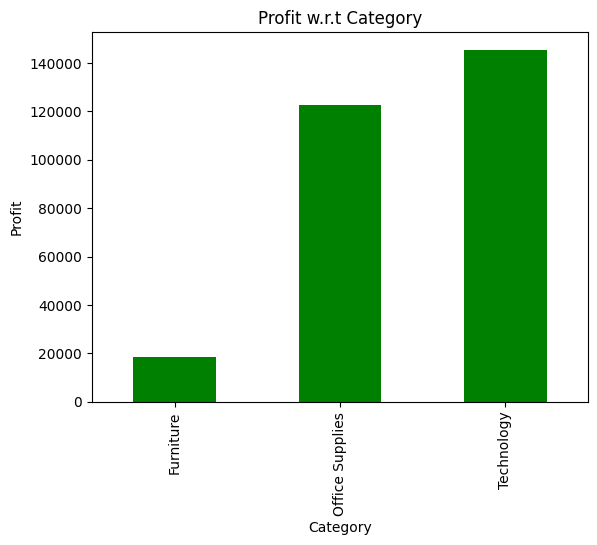

In [29]:
category_profit.plot(kind='bar', color='green')

plt.title('Profit w.r.t Category')
plt.ylabel('Profit')

plt.savefig(
    'visuals/profit_by_category.png',
    bbox_inches='tight'
)

plt.show()

**Customer Segment Analysis**

In [30]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


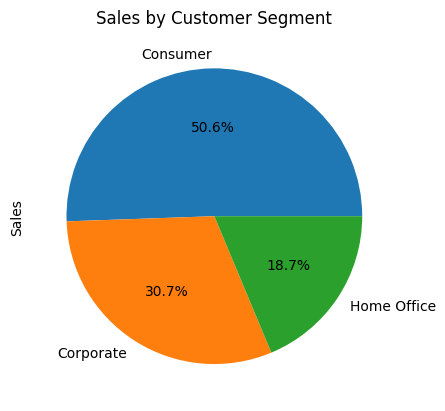

In [31]:
segment_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title('Sales by Customer Segment')

plt.savefig(
    'visuals/sales_by_customer_segment.png',
    bbox_inches='tight'
)

plt.show()

**Discount Impact**

In [32]:
df[['Discount','Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


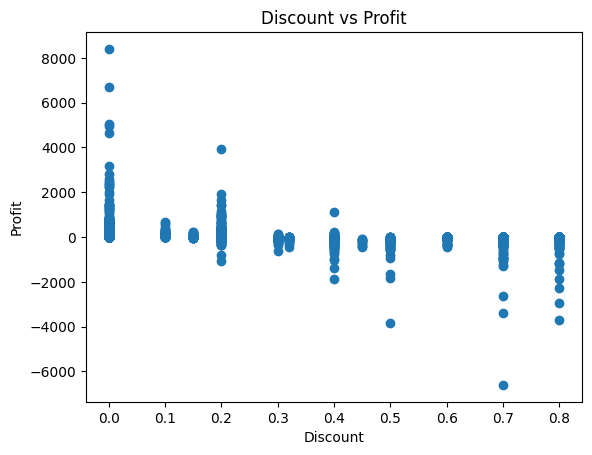

In [40]:
plt.scatter(df['Discount'], df['Profit'])

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')

plt.savefig(
    'visuals/discount_vs_proft.png',
    bbox_inches='tight'
)

plt.show()

**Insight**

Larger discounts appear to reduce profitability in many transactions.

**Top 10 States**

In [44]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
top_states.head(10)

,Sales
State,
California,457687.6315
New York,310876.2710
Texas,170188.0458
Washington,138641.2700
Pennsylvania,116511.9140
Florida,89473.7080
Illinois,80166.1010
Ohio,78258.1360
Michigan,76269.6140


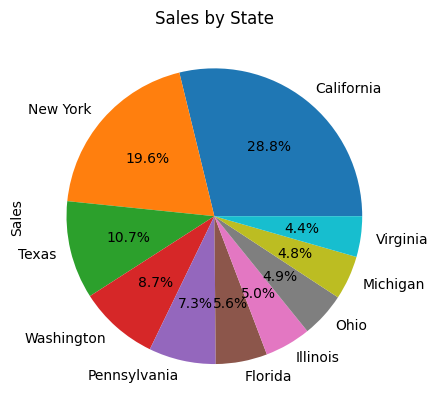

In [41]:
top_states.sort_values(ascending=False).head(10).plot(kind='pie', autopct='%1.1f%%')

plt.title('Sales by State')

plt.savefig(
    'visuals/sales_by_state.png',
    bbox_inches='tight'
)

plt.show()

**Top 10 Cities by Profit**

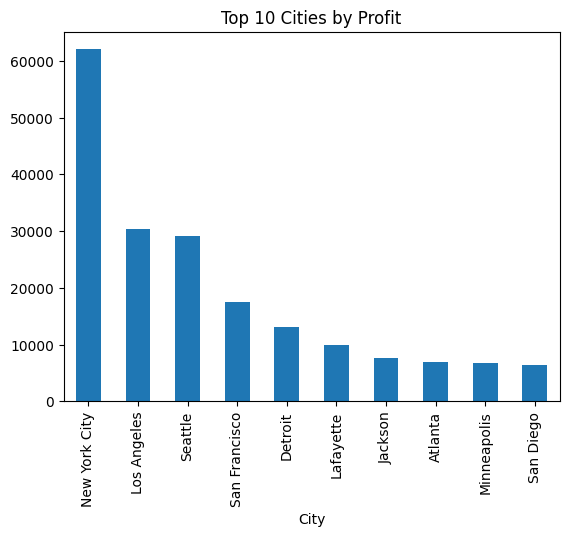

In [45]:
top_cities = (
    df.groupby('City')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_cities.plot(kind='bar')

plt.title('Top 10 Cities by Profit')

plt.savefig(
    'visuals/top_10_cities_profit.png',
    bbox_inches='tight'
)

plt.show()

**Correlation Heatmap**

In [42]:
import seaborn as sns

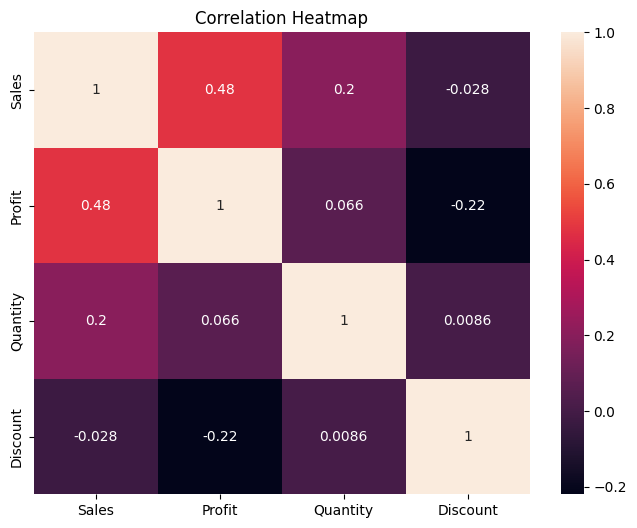

In [43]:
numeric_cols = [
    'Sales',
    'Profit',
    'Quantity',
    'Discount'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True
)

plt.title('Correlation Heatmap')

plt.savefig(
    'visuals/correlation_heatmap.png',
    bbox_inches='tight'
)

plt.show()

# **Executive Summary**

**Key Findings**

This project analyzed 9,994 retail transactions from a Superstore dataset to identify key sales and profitability trends across regions, product categories, and customer segments.

The analysis revealed total sales of approximately 2.30 dollars million and total profit of approximately $286,397. The West region generated the highest sales revenue, indicating strong market performance and growth potential. Among product categories, Technology achieved both the highest sales and the highest profit, making it the most valuable category for the business.

Customer segment analysis showed that Consumer customers contributed the largest share of total sales, followed by Corporate and Home Office customers. This suggests that marketing and retention strategies focused on Consumer customers could have the greatest impact on future revenue growth.

The study also examined the relationship between discounts and profitability. A negative correlation was observed between discount levels and profit, indicating that excessive discounting may reduce overall profitability. Businesses should carefully evaluate discount strategies to balance customer acquisition and profit margins.

Overall, the findings suggest that the company should continue investing in high-performing regions and product categories while optimizing discount policies to improve profitability and long-term business performance.
